In [1]:
!pip install -q transformers accelerate gradio wandb
# torchvision, torch already on Kaggle T4
import subprocess, sys
print(f"Python {sys.version}")
print("✓ installs done")

Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
✓ installs done


In [2]:

import os, json, random, math, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models as tv_models
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ── Device ──────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Paths ────────────────────────────────────────────────────
DATASET_ROOT = Path("/kaggle/input/datasets/thedownhill/art-images-drawings-painting-sculpture-engraving")
# Nested structure: dataset_updated/training_set/training_set/{class}/
TRAIN_DIR = DATASET_ROOT / "dataset"/ "dataset_updated" / "training_set"
VAL_DIR   = DATASET_ROOT / "dataset"/ "dataset_updated" / "validation_set"
WORK_DIR  = Path("/kaggle/working")
CAPTIONS_FILE = WORK_DIR / "captions.jsonl"
CKPT_PATH     = WORK_DIR / "multimodal_art_gen.pt"

# ── Model hyper-params ───────────────────────────────────────
IMG_SIZE        = 128       # 128×128 on T4 (set 256 for production)
NUM_DS          = 3         # downsample stages in encoder
SPATIAL         = IMG_SIZE  // (2 ** NUM_DS)   # = 16
LATENT_DIM      = 256       # VQ embedding dim
NUM_VQ          = 1024       # codebook size
BASE_CH         = 64        # encoder base channels
NUM_STYLES      = 5         # art style classes
NUM_PREFIX      = 8         # GPT-2 prefix tokens from cross-attn bridge
MAX_CAP_LEN     = 64        # caption token length

# ── Training hyper-params ────────────────────────────────────
BATCH_SIZE      = 16
EPOCHS_VQGAN    = 40        # VQGAN warm-up epochs
EPOCHS_JOINT    = 20        # joint VQGAN + caption epochs
LR_GEN          = 2e-4
LR_CAP          = 5e-5
LR_DISC         = 4e-4
LAMBDA_PERC     = 0.3
LAMBDA_GAN      = 0.5
DISC_START_EP   = 10         # GAN kicks in after this epoch

# ── Style metadata ───────────────────────────────────────────
STYLE_NAMES   = ["drawings", "engraving", "iconography", "painting", "sculpture"]
STYLE_TO_IDX  = {s: i for i, s in enumerate(STYLE_NAMES)}
STYLE_DISPLAY = {
    "drawings"    : "a pencil drawing",
    "engraving"   : "an engraving",
    "iconography" : "an iconographic artwork",
    "painting"    : "an oil painting",
    "sculpture"   : "a sculpture",
}

print(f"\nSpatial after encoder : {SPATIAL}×{SPATIAL} ({SPATIAL**2} VQ tokens shared latent)")
print(f"VQ codebook           : {NUM_VQ} codes × {LATENT_DIM}-dim")
print(f"GPT-2 prefix tokens   : {NUM_PREFIX}")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

Spatial after encoder : 16×16 (256 VQ tokens shared latent)
VQ codebook           : 1024 codes × 256-dim
GPT-2 prefix tokens   : 8



 Split : train
 Path  : /kaggle/input/datasets/thedownhill/art-images-drawings-painting-sculpture-engraving/dataset/dataset_updated/training_set
  drawings       :  1107 images  [drawings]
  engraving      :   760 images  [engraving]
  iconography    :  2079 images  [iconography]
  painting       :  2128 images  [painting]
  sculpture      :  1745 images  [sculpture]
  TOTAL          :  7819 images

 Split : val
 Path  : /kaggle/input/datasets/thedownhill/art-images-drawings-painting-sculpture-engraving/dataset/dataset_updated/validation_set
  drawings       :   122 images  [drawings]
  engraving      :    84 images  [engraving]
  iconography    :   231 images  [iconography]
  painting       :   236 images  [painting]
  sculpture      :   193 images  [sculpture]
  TOTAL          :   866 images


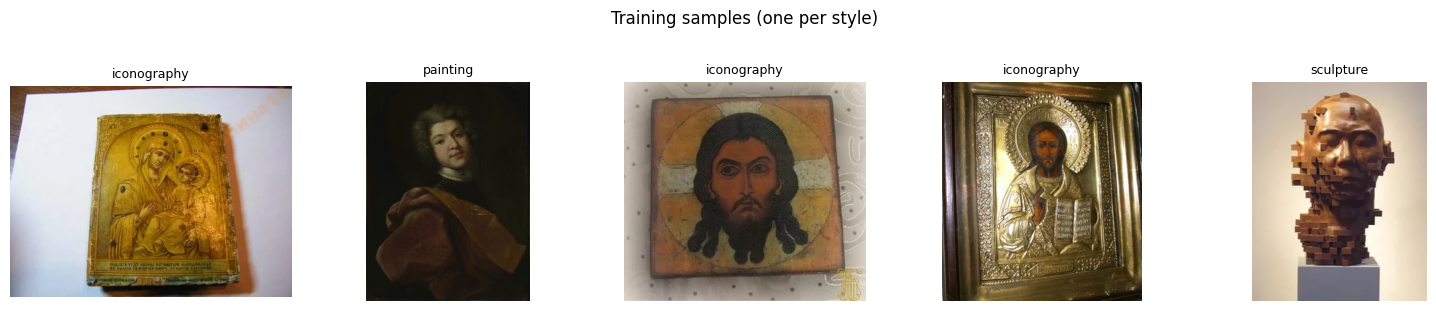

In [3]:
def verify_and_list(base_dir: Path, split: str = "train") -> list[str]:
    """List all valid image paths under base_dir/{class}/ subdirs."""
    print(f"\n{'='*52}")
    print(f" Split : {split}")
    print(f" Path  : {base_dir}")
    print(f"{'='*52}")

    if not base_dir.exists():
        print(f"  ✗ Directory not found. Trying to auto-detect…")
        # Try to find the actual path by searching one level up
        parent = base_dir.parent
        for child in sorted(parent.iterdir()):
            if child.is_dir():
                print(f"    Found: {child}")
        return []

    all_paths = []
    found_classes = []
    for entry in sorted(base_dir.iterdir()):
        if entry.is_dir():
            found_classes.append(entry.name)

    # Map found dirs to expected STYLE_NAMES (fuzzy)
    for style in STYLE_NAMES:
        style_dir = base_dir / style
        if not style_dir.exists():
            # try case-insensitive
            for c in found_classes:
                if c.lower() == style.lower():
                    style_dir = base_dir / c
                    break
        if style_dir.exists():
            imgs = sorted([
                str(p) for p in style_dir.iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
            ])
            print(f"  {style:15s}: {len(imgs):5d} images  [{style_dir.name}]")
            all_paths.extend([(p, style) for p in imgs])
        else:
            print(f"  {style:15s}: ✗ NOT FOUND (checked {style_dir})")

    print(f"  {'TOTAL':15s}: {len(all_paths):5d} images")
    return all_paths

train_paths = verify_and_list(TRAIN_DIR, "train")
val_paths   = verify_and_list(VAL_DIR,   "val")

# ── Quick mosaic ─────────────────────────────────────────────
def show_samples(paths_labels, n=5, title="Samples"):
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    sampled = random.sample(paths_labels, min(n, len(paths_labels)))
    for ax, (path, style) in zip(axes, sampled):
        try:
            img = Image.open(path).convert("RGB")
            ax.imshow(img)
        except Exception:
            pass
        ax.set_title(style, fontsize=9)
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

if train_paths:
    show_samples(train_paths, title="Training samples (one per style)")

In [4]:
from transformers import BlipProcessor, BlipForConditionalGeneration

def generate_blip_captions(
    train_paths: list,
    max_per_style: int = 400,
    force: bool = False
) -> list[dict]:
    """
    Run BLIP-base on training images and save style-aware captions.
    Cached in CAPTIONS_FILE to avoid re-running.
    Falls back to template captions if BLIP unavailable.
    """
    if CAPTIONS_FILE.exists() and not force:
        records = [json.loads(l) for l in CAPTIONS_FILE.read_text().splitlines() if l.strip()]
        print(f"✓ Loaded {len(records)} cached captions from {CAPTIONS_FILE}")
        return records

    records = []

    # ── Try BLIP (requires internet on Kaggle) ──────────────
    try:
        print("Loading BLIP-base…")
        proc  = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
        blip  = BlipForConditionalGeneration.from_pretrained(
            "Salesforce/blip-image-captioning-base", torch_dtype=torch.float16
        ).to(DEVICE).eval()
        use_blip = True
        print("✓ BLIP loaded")
    except Exception as e:
        print(f"⚠ BLIP unavailable ({e}). Using template captions.")
        use_blip = False

    # ── Per-style sampling ───────────────────────────────────
    by_style: dict[str, list[str]] = {s: [] for s in STYLE_NAMES}
    for path, style in train_paths:
        by_style.get(style, []).append(path)

    for style, paths in by_style.items():
        paths = paths[:max_per_style]
        print(f"\n  {style}: {len(paths)} images")
        for path in tqdm(paths, desc=f"  {style}", leave=False):
            if use_blip:
                try:
                    img = Image.open(path).convert("RGB")
                    inputs = proc(img, return_tensors="pt").to(DEVICE)
                    with torch.no_grad():
                        out = blip.generate(**inputs, max_new_tokens=35)
                    base_cap = proc.decode(out[0], skip_special_tokens=True)
                except Exception:
                    base_cap = "an artwork"
            else:
                base_cap = "an artwork"

            # Style-aware wrapping (bonus requirement from spec)
            caption = f"{STYLE_DISPLAY[style]} of {base_cap}"
            records.append({
                "path"      : path,
                "style"     : style,
                "style_idx" : STYLE_TO_IDX[style],
                "caption"   : caption,
            })

    # ── Free BLIP VRAM ───────────────────────────────────────
    if use_blip:
        del blip, proc
        torch.cuda.empty_cache()

    # ── Save JSONL ───────────────────────────────────────────
    WORK_DIR.mkdir(exist_ok=True)
    with CAPTIONS_FILE.open("w") as f:
        for r in records:
            f.write(json.dumps(r) + "\n")
    print(f"\n✓ Saved {len(records)} captions → {CAPTIONS_FILE}")

    # ── Sample preview ───────────────────────────────────────
    print("\nSample captions:")
    for r in random.sample(records, min(5, len(records))):
        print(f"  [{r['style']:12s}] {r['caption']}")

    return records


records = generate_blip_captions(train_paths, max_per_style=400)
print(f"\nTotal training records : {len(records)}")

Loading BLIP-base…


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...


  painting: 400 images


  painting:   0%|          | 0/400 [00:00<?, ?it/s]


  sculpture: 400 images


  sculpture:   0%|          | 0/400 [00:00<?, ?it/s]


✓ Saved 2000 captions → /kaggle/working/captions.jsonl

Sample captions:
  [painting    ] an oil painting of a portrait of a man in a black coat and white shirt
  [engraving   ] an engraving of a drawing of a group of people in a landscape
  [engraving   ] an engraving of the ann of the ann of the ann of the ann of the ann of the ann of the ann of
  [painting    ] an oil painting of a painting of a man in uniform pointing at a group of soldiers
  [iconography ] an iconographic artwork of the icon of the virgin and child

Total training records : 2000


In [14]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token   # GPT-2 uses eos as pad
print(f"Vocabulary size : {len(tokenizer)}")


TRANSFORM_TRAIN = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), 
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.RandomGrayscale(p=0.05),  
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

TRANSFORM_VAL = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])


class ArtCaptionDataset(Dataset):
    def __init__(self, records: list[dict],
                 transform=None,
                 max_cap_len: int = MAX_CAP_LEN):
        self.records     = records
        self.transform   = transform or TRANSFORM_TRAIN
        self.max_cap_len = max_cap_len

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        rec = self.records[idx]

        # ── Image ──────────────────────────────────────────
        try:
            img = Image.open(rec["path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (128, 128, 128))
        img = self.transform(img)           # (3, H, W)

        # ── Style ──────────────────────────────────────────
        style_idx = torch.tensor(rec["style_idx"], dtype=torch.long)

        # ── Caption tokens ─────────────────────────────────
        enc = tokenizer(
            rec["caption"],
            max_length=self.max_cap_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        cap_ids  = enc["input_ids"].squeeze(0)       # (T,)
        cap_mask = enc["attention_mask"].squeeze(0)  # (T,)

        return img, style_idx, cap_ids, cap_mask


# ── Build loaders ────────────────────────────────────────────
train_dataset = ArtCaptionDataset(records)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,              # small number
    pin_memory=True,
    persistent_workers=True     # 🔥 IMPORTANT
)

print(f"Dataset size   : {len(train_dataset)}")
print(f"Batches/epoch  : {len(train_loader)}")

# ── Sanity check one batch ────────────────────────────────────
imgs, sidx, cids, cmask = next(iter(train_loader))
print(f"\nBatch check:")
print(f"  images  : {imgs.shape}  range [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"  style   : {sidx.shape}  values {sidx.unique().tolist()}")
print(f"  cap_ids : {cids.shape}")
print(f"  cap_mask: {cmask.shape}")
print(f"\nDecoded caption[0]: {tokenizer.decode(cids[0], skip_special_tokens=True)}")

Vocabulary size : 50257
Dataset size   : 2000
Batches/epoch  : 125

Batch check:
  images  : torch.Size([16, 3, 128, 128])  range [-1.00, 1.00]
  style   : torch.Size([16])  values [0, 1, 2, 3, 4]
  cap_ids : torch.Size([16, 64])
  cap_mask: torch.Size([16, 64])

Decoded caption[0]: a pencil drawing of a painting of a building with people walking by


In [15]:
# ============================================================
# CELL 6 — VQVAE: Encoder + VectorQuantizer + Decoder
# ============================================================

# ── Shared primitives ────────────────────────────────────────
def get_ch(stage: int, base: int = BASE_CH, cap: int = 512) -> int:
    """Channel count at encoder stage (doubles each stage, capped)."""
    return min(base * (2 ** stage), cap)


class ResBlock(nn.Module):
    """Pre-activation residual block with GroupNorm."""
    def __init__(self, ch: int):
        super().__init__()
        g = min(32, ch)
        self.net = nn.Sequential(
            nn.GroupNorm(g, ch),
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.GroupNorm(g, ch),
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.net(x)


# ── Encoder ──────────────────────────────────────────────────
class VQEncoder(nn.Module):
    """
    IMG_SIZE×IMG_SIZE → (LATENT_DIM, SPATIAL, SPATIAL)
    3 × stride-2 conv → 128→64→32→16 spatial (for IMG_SIZE=128, NUM_DS=3)
    """
    def __init__(self,
                 in_ch: int = 3,
                 base_ch: int = BASE_CH,
                 num_ds: int = NUM_DS,
                 latent_dim: int = LATENT_DIM):
        super().__init__()
        layers = []
        ch = base_ch
        layers.append(nn.Conv2d(in_ch, ch, 3, padding=1))
        for i in range(num_ds):
            out_ch = get_ch(i + 1)
            layers += [ResBlock(ch), ResBlock(ch),
                       nn.Conv2d(ch, out_ch, 4, stride=2, padding=1)]
            ch = out_ch
        layers += [ResBlock(ch), ResBlock(ch),
                   nn.GroupNorm(min(32, ch), ch), nn.SiLU(),
                   nn.Conv2d(ch, latent_dim, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)   # (B, LATENT_DIM, SPATIAL, SPATIAL)


# ── Vector Quantizer ─────────────────────────────────────────
class VectorQuantizer(nn.Module):
    """
    Straight-through EMA-style VQ.
    Returns z_q (same shape as z), vq_loss (scalar), indices (B,H,W).
    """
    def __init__(self,
                 num_embeddings: int = NUM_VQ,
                 embedding_dim: int  = LATENT_DIM,
                 commitment_cost: float = 0.25):
        super().__init__()
        self.num_embeddings  = num_embeddings
        self.embedding_dim   = embedding_dim
        self.commitment_cost = commitment_cost

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        nn.init.uniform_(self.embedding.weight,
                         -1.0 / num_embeddings, 1.0 / num_embeddings)

    def forward(self, z: torch.Tensor):
        """z : (B, C, H, W) → z_q, vq_loss, indices"""
        B, C, H, W = z.shape
        # Flatten to (B*H*W, C)
        z_flat = z.permute(0, 2, 3, 1).reshape(-1, C)

        # Squared distances to all codebook entries
        dists = (
            z_flat.pow(2).sum(1, keepdim=True)       # (N, 1)
            + self.embedding.weight.pow(2).sum(1)     # (K,)
            - 2.0 * (z_flat @ self.embedding.weight.T)  # (N, K)
        )                                              # (N, K)

        indices = dists.argmin(1)                      # (N,)
        z_q = self.embedding(indices).view(B, H, W, C).permute(0, 3, 1, 2)  # (B,C,H,W)

        # VQ loss: codebook_loss + commitment_loss
        vq_loss = (
            F.mse_loss(z_q.detach(), z)          # move codebook → z
            + self.commitment_cost
            * F.mse_loss(z_q, z.detach())         # move z → codebook
        )

        # Straight-through: gradient bypasses quantization
        z_q_st = z + (z_q - z).detach()

        return z_q_st, vq_loss, indices.view(B, H, W)


# ── Decoder ──────────────────────────────────────────────────
class VQDecoder(nn.Module):
    """
    (LATENT_DIM, SPATIAL, SPATIAL) → (3, IMG_SIZE, IMG_SIZE)
    Mirror of VQEncoder: 3 × stride-2 ConvTranspose.
    """
    def __init__(self,
                 latent_dim: int = LATENT_DIM,
                 base_ch: int    = BASE_CH,
                 num_us: int     = NUM_DS,    # upsample stages = downsample stages
                 out_ch: int     = 3):
        super().__init__()
        # Start from the deepest channel count
        ch_start = get_ch(num_us)
        layers   = [nn.Conv2d(latent_dim, ch_start, 3, padding=1)]
        ch       = ch_start
        for i in range(num_us - 1, -1, -1):
            out_ch_i = get_ch(i)
            layers += [ResBlock(ch), ResBlock(ch),
                       nn.ConvTranspose2d(ch, out_ch_i, 4, stride=2, padding=1)]
            ch = out_ch_i
        layers += [ResBlock(ch), ResBlock(ch),
                   nn.GroupNorm(min(32, ch), ch), nn.SiLU(),
                   nn.Conv2d(ch, out_ch, 3, padding=1),
                   nn.Tanh()]
        self.net = nn.Sequential(*layers)

    def forward(self, z_q: torch.Tensor) -> torch.Tensor:
        return self.net(z_q)   # (B, 3, IMG_SIZE, IMG_SIZE)


# ── Shape verification ───────────────────────────────────────
with torch.no_grad():
    _enc = VQEncoder().to(DEVICE)
    _vq  = VectorQuantizer().to(DEVICE)
    _dec = VQDecoder().to(DEVICE)

    _x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    _ze = _enc(_x)
    print(f"Encoder output  : {tuple(_ze.shape)}")   # (2, 256, 16, 16)

    _zq, _loss, _idx = _vq(_ze)
    print(f"VQ output       : {tuple(_zq.shape)},  VQ-loss = {_loss.item():.4f}")
    print(f"VQ indices      : {tuple(_idx.shape)}")  # (2, 16, 16)

    _recon = _dec(_zq)
    print(f"Decoder output  : {tuple(_recon.shape)}")  # (2, 3, 128, 128)

    del _enc, _vq, _dec, _x, _ze, _zq, _idx, _recon
    torch.cuda.empty_cache()

Encoder output  : (2, 256, 16, 16)
VQ output       : (2, 256, 16, 16),  VQ-loss = 0.1542
VQ indices      : (2, 16, 16)
Decoder output  : (2, 3, 128, 128)


In [16]:
# ============================================================
# CELL 7 — CaptionDecoder: VQ features → captions via GPT-2
#
# Design:
#   VQ features (B,C,H,W) become K and V in cross-attention.
#   8 learnable query vectors → 8 prefix tokens (B,8,768).
#   These prefix tokens are prepended to GPT-2's input embeddings.
#   Both image and caption decoders read the SAME z_q → shared latent.
# ============================================================
from transformers import GPT2LMHeadModel


class CaptionDecoder(nn.Module):
    def __init__(self,
                 vq_dim: int    = LATENT_DIM,
                 spatial: int   = SPATIAL,
                 num_prefix: int = NUM_PREFIX,
                 max_cap_len: int = MAX_CAP_LEN):
        super().__init__()
        self.num_prefix  = num_prefix
        self.max_cap_len = max_cap_len
        self.vq_dim      = vq_dim

        # ── GPT-2 small ─────────────────────────────────────
        self.gpt2   = GPT2LMHeadModel.from_pretrained("gpt2")
        self.gpt_dim = self.gpt2.config.n_embd   # 768

        # ── Cross-attention bridge ───────────────────────────
        # VQ features → K, V  |  learnable queries → prefix tokens
        self.vq_proj = nn.Sequential(
            nn.Linear(vq_dim, self.gpt_dim),
            nn.GELU(),
            nn.Linear(self.gpt_dim, self.gpt_dim),
        )
        self.prefix_queries = nn.Parameter(
            torch.randn(1, num_prefix, self.gpt_dim) * 0.02
        )
        self.cross_attn = nn.MultiheadAttention(
            embed_dim   = self.gpt_dim,
            num_heads   = 8,
            batch_first = True,
            dropout     = 0.1,
        )
        self.cross_norm = nn.LayerNorm(self.gpt_dim)

        # Partially freeze GPT-2 (first 6 of 12 layers) for stability
        for layer in self.gpt2.transformer.h[:6]:
            for p in layer.parameters():
                p.requires_grad_(False)

    # ── Build prefix from VQ features ────────────────────────
    def _build_prefix(self, z_q: torch.Tensor) -> torch.Tensor:
        """
        z_q  : (B, C, H, W)
        return: (B, num_prefix, gpt_dim)
        """
        B, C, H, W = z_q.shape
        # Flatten spatial dims → (B, H*W, C)  →  project to gpt_dim
        kv = self.vq_proj(
            z_q.permute(0, 2, 3, 1).reshape(B, H * W, C)
        )                                                   # (B, H*W, gpt_dim)
        queries = self.prefix_queries.expand(B, -1, -1)     # (B, P, gpt_dim)
        prefix, _ = self.cross_attn(queries, kv, kv)        # (B, P, gpt_dim)
        return self.cross_norm(prefix)

    # ── Training forward ─────────────────────────────────────
    def forward(self,
                z_q: torch.Tensor,
                cap_ids: torch.Tensor,
                cap_mask: torch.Tensor) -> torch.Tensor:
        """
        z_q     : (B, C, H, W)  — quantized VQ features (detached recommended)
        cap_ids : (B, T)         — tokenized captions (padded to MAX_CAP_LEN)
        cap_mask: (B, T)         — 1 for real tokens, 0 for pad
        Returns : scalar CE loss
        """
        prefix   = self._build_prefix(z_q)                 # (B, P, G)
        B, T, G  = *cap_ids.shape[:1], cap_ids.shape[1], self.gpt_dim

        # Token embeddings (GPT-2 wte)
        tok_emb  = self.gpt2.transformer.wte(cap_ids)      # (B, T, G)

        # Concatenate prefix + caption embeddings
        inp_emb  = torch.cat([prefix, tok_emb], dim=1)     # (B, P+T, G)

        # Attention mask: prefix always attended
        pfx_mask = torch.ones(cap_ids.size(0), self.num_prefix,
                               device=z_q.device)
        full_mask = torch.cat([pfx_mask, cap_mask], dim=1) # (B, P+T)

        out    = self.gpt2(inputs_embeds=inp_emb,
                           attention_mask=full_mask)
        logits = out.logits                                 # (B, P+T, vocab)

        # Shift: logit[P+t] predicts cap_ids[t+1]
        cap_logits  = logits[:, self.num_prefix:-1, :]     # (B, T-1, vocab)
        cap_targets = cap_ids[:, 1:]                       # (B, T-1)

        pad_id = tokenizer.eos_token_id
        loss   = F.cross_entropy(
            cap_logits.reshape(-1, cap_logits.size(-1)),
            cap_targets.reshape(-1),
            ignore_index=pad_id,
        )
        return loss

    # ── Autoregressive inference ──────────────────────────────
    @torch.no_grad()
    def generate(self,
                 z_q: torch.Tensor,
                 max_new: int = 48,
                 temperature: float = 0.85,
                 top_k: int = 50) -> list[str]:
        """Generate captions from VQ features using top-k sampling."""
        self.eval()
        prefix = self._build_prefix(z_q)               # (B, P, G)
        B = prefix.shape[0]

        bos_id = tokenizer.bos_token_id or tokenizer.eos_token_id
        bos_emb = self.gpt2.transformer.wte(
            torch.full((B, 1), bos_id, device=z_q.device, dtype=torch.long)
        )                                               # (B, 1, G)
        inp_emb = torch.cat([prefix, bos_emb], dim=1)  # (B, P+1, G)

        out     = self.gpt2(inputs_embeds=inp_emb, use_cache=True)
        past_kv = out.past_key_values
        logits  = out.logits[:, -1, :]                 # (B, vocab)

        generated = []
        eos_id    = tokenizer.eos_token_id

        for _ in range(max_new):
            # Top-k filter
            if top_k > 0:
                v, _ = logits.topk(top_k)
                logits = logits.masked_fill(logits < v[:, [-1]], float("-inf"))
            probs    = F.softmax(logits / temperature, dim=-1)
            next_tok = torch.multinomial(probs, 1)      # (B, 1)
            generated.append(next_tok)

            if (next_tok == eos_id).all():
                break

            tok_emb = self.gpt2.transformer.wte(next_tok)  # (B,1,G)
            out     = self.gpt2(inputs_embeds=tok_emb,
                                past_key_values=past_kv,
                                use_cache=True)
            past_kv = out.past_key_values
            logits  = out.logits[:, -1, :]

        if not generated:
            return [""] * B
        ids = torch.cat(generated, dim=1)  # (B, steps)
        return [tokenizer.decode(r.tolist(), skip_special_tokens=True) for r in ids]


# ── Shape check ──────────────────────────────────────────────
with torch.no_grad():
    _cap = CaptionDecoder().to(DEVICE)
    _zq  = torch.randn(2, LATENT_DIM, SPATIAL, SPATIAL, device=DEVICE)
    _ids = torch.randint(0, 50257, (2, MAX_CAP_LEN), device=DEVICE)
    _msk = torch.ones(2, MAX_CAP_LEN, device=DEVICE)

    _loss = _cap(_zq, _ids, _msk)
    print(f"Caption CE loss (random) : {_loss.item():.4f}")
    _caps = _cap.generate(_zq)
    print(f"Generated (untrained)    : {_caps}")

    total = sum(p.numel() for p in _cap.parameters() if p.requires_grad)
    print(f"Trainable caption params : {total:,}")
    del _cap, _zq, _ids, _msk
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Caption CE loss (random) : 13.7521
Generated (untrained)    : ["\nR. It is't even and and and, and a nc.\n\n\nA big, what's the point is the point is this.\n\n\n\nA/A)\n\n\n\nIn a given it", '". The three, be:\n\n1.\n(3-4-C-F) (n. They come back\n\n\n\n1\n\n\n(3-2)\n\n\n\n2-3\n']
Trainable caption params : 85,070,592


In [17]:
# ============================================================
# CELL 8 — PatchGAN Discriminator (hinge GAN loss)
# ============================================================

class PatchDiscriminator(nn.Module):
    """
    70×70 PatchGAN discriminator.
    Input: (B, 3, H, W) → (B, 1, H', W') patch scores.
    """
    def __init__(self, in_ch: int = 3, channels: list = [64, 128, 256]):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, channels[0], 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
        ]
        for i in range(len(channels) - 1):
            layers += [
                nn.Conv2d(channels[i], channels[i + 1], 4, stride=2, padding=1),
                nn.GroupNorm(min(32, channels[i + 1]), channels[i + 1]),
                nn.LeakyReLU(0.2, inplace=True),
            ]
        layers.append(nn.Conv2d(channels[-1], 1, 4, padding=1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ── Test ─────────────────────────────────────────────────────
_disc = PatchDiscriminator().to(DEVICE)
_x    = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
print(f"Discriminator output shape : {_disc(_x).shape}")
del _disc, _x
torch.cuda.empty_cache()

Discriminator output shape : torch.Size([2, 1, 15, 15])


In [18]:
# ============================================================
# CELL 9 — MultimodalArtGen: unified model + perceptual loss
# ============================================================

class MultimodalArtGen(nn.Module):
    """
    VQGAN-Captioner: both stylized image and caption emerge from
    the SAME shared VQ discrete latent (z_q).

    Training heads:
      • Image: L1 + perceptual + VQ + GAN hinge
      • Caption: CE vs BLIP captions (z_q detached for stability)

    Inference from seed:
      seed → manual_seed → z_noise → style_bias → VQ → z_q
           → image decoder AND GPT-2 caption head
    """

    def __init__(self):
        super().__init__()
        self.encoder    = VQEncoder()
        self.quantizer  = VectorQuantizer()
        self.decoder    = VQDecoder()
        self.cap_dec    = CaptionDecoder()
        self.disc       = PatchDiscriminator()

        # Style bias: adds per-class offset to encoder output
        self.style_emb  = nn.Embedding(NUM_STYLES, LATENT_DIM)
        nn.init.normal_(self.style_emb.weight, 0.0, 0.02)

        # Perceptual network (frozen VGG-16 relu3_3)
        vgg = tv_models.vgg16(weights="IMAGENET1K_V1")
        self.perc_net = nn.Sequential(*list(vgg.features[:16])).eval()
        for p in self.perc_net.parameters():
            p.requires_grad_(False)

        # ImageNet normalization for perceptual loss
        self.register_buffer(
            "perc_mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        )
        self.register_buffer(
            "perc_std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        )

    # ── Encoding pipeline ─────────────────────────────────────
    def encode(self, x: torch.Tensor, style_idx: torch.Tensor):
        """x→ encoder → style-bias → VQ → z_q"""
        z_e = self.encoder(x)                             # (B, C, H, W)
        bias = self.style_emb(style_idx)                   # (B, C)
        z_e  = z_e + bias.unsqueeze(-1).unsqueeze(-1)     # broadcast
        return self.quantizer(z_e)                         # z_q, vq_loss, indices

    # ── Perceptual loss ───────────────────────────────────────
    def perceptual_loss(self, x_recon: torch.Tensor, x_real: torch.Tensor) -> torch.Tensor:
        # Denormalize [-1,1] → imagenet stats
        def prep(t):
            return (t * 0.5 + 0.5 - self.perc_mean) / self.perc_std
        return F.l1_loss(self.perc_net(prep(x_recon)),
                         self.perc_net(prep(x_real)).detach())

    # ── Full training forward ─────────────────────────────────
    def forward(self,
                x: torch.Tensor,
                style_idx: torch.Tensor,
                cap_ids: torch.Tensor,
                cap_mask: torch.Tensor,
                use_gan: bool = False):
        """Returns dict of losses + reconstructed image."""
        z_q, vq_loss, _ = self.encode(x, style_idx)
        x_recon          = self.decoder(z_q)

        recon_loss = F.l1_loss(x_recon, x)
        perc_loss  = self.perceptual_loss(x_recon, x)

        # Caption loss (detach z_q: keep VQ training independent)
        cap_loss = self.cap_dec(z_q.detach(), cap_ids, cap_mask)

        # GAN
        if use_gan:
            fake_logits = self.disc(x_recon)
            real_logits = self.disc(x)
            g_gan_loss  = -fake_logits.mean()
            d_real      = F.relu(1.0 - real_logits).mean()
            d_fake      = F.relu(1.0 + fake_logits.detach()).mean()
            d_loss      = (d_real + d_fake) * 0.5
        else:
            g_gan_loss = torch.tensor(0.0, device=x.device)
            d_loss     = torch.tensor(0.0, device=x.device)

        gen_loss = (
            recon_loss
            + LAMBDA_PERC * perc_loss
            + vq_loss
            + (LAMBDA_GAN * g_gan_loss if use_gan else 0.0)
        )

        return {
            "gen_loss"  : gen_loss,
            "d_loss"    : d_loss,
            "cap_loss"  : cap_loss,
            "recon_loss": recon_loss,
            "perc_loss" : perc_loss,
            "vq_loss"   : vq_loss,
            "x_recon"   : x_recon,
        }

    # ── Seed-based inference ──────────────────────────────────
    @torch.no_grad()
    def generate(self,
                 seed: int,
                 style_name: str,
                 n: int = 1,
                 temperature: float = 0.85) -> tuple[torch.Tensor, list[str]]:
        """
        Unified generation from a single integer seed.
        Both image and caption come from the same z_q.
        """
        self.eval()
        dev = next(self.parameters()).device
        torch.manual_seed(seed)

        style_idx = torch.tensor(
            [STYLE_TO_IDX[style_name]] * n, device=dev
        )
        # Random latent + style bias → VQ → shared discrete latent
        z_noise = torch.randn(n, LATENT_DIM, SPATIAL, SPATIAL, device=dev)
        bias    = self.style_emb(style_idx).unsqueeze(-1).unsqueeze(-1)
        z_biased = z_noise + bias

        z_q, _, _ = self.quantizer(z_biased)       # quantize to codebook

        # ── Image head ─────────────────────────────────────
        images = self.decoder(z_q)                 # (n, 3, H, W) ∈ [-1,1]
        images = (images * 0.5 + 0.5).clamp(0, 1) # → [0,1]

        # ── Caption head (same z_q) ──────────────────────────
        captions = self.cap_dec.generate(z_q, temperature=temperature)

        return images, captions


# ── Instantiate + param count ─────────────────────────────────
model = MultimodalArtGen().to(DEVICE)

def count_params(m, trainable_only=True):
    ps = [p for p in m.parameters() if (p.requires_grad or not trainable_only)]
    return sum(p.numel() for p in ps)

print(f"Total params (encoder+VQ+decoder) : {count_params(model.encoder)+count_params(model.quantizer)+count_params(model.decoder):,}")
print(f"Caption decoder trainable         : {count_params(model.cap_dec):,}")
print(f"Discriminator                     : {count_params(model.disc):,}")
print(f"Total trainable                   : {count_params(model):,}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params (encoder+VQ+decoder) : 32,175,235
Caption decoder trainable         : 85,070,592
Discriminator                     : 663,745
Total trainable                   : 117,910,852


In [ ]:
# ============================================================
# CELL 10 — Training (FIXED)
# ============================================================
from torch.cuda.amp import GradScaler, autocast

# ── Separate optimizer groups ─────────────────────────────────
vqgan_params = (
    list(model.encoder.parameters())
    + list(model.quantizer.parameters())
    + list(model.decoder.parameters())
    + list(model.style_emb.parameters())
)
cap_params  = list(model.cap_dec.parameters())
disc_params = list(model.disc.parameters())

opt_vqgan = torch.optim.AdamW(vqgan_params, lr=LR_GEN,  betas=(0.5, 0.9))
opt_cap   = torch.optim.AdamW(cap_params,   lr=LR_CAP,  betas=(0.9, 0.999))
opt_disc  = torch.optim.AdamW(disc_params,  lr=LR_DISC, betas=(0.5, 0.9))

# LR schedulers
total_epochs = EPOCHS_VQGAN + EPOCHS_JOINT
sch_vqgan = torch.optim.lr_scheduler.CosineAnnealingLR(opt_vqgan, total_epochs)
sch_cap   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cap,   total_epochs)
sch_disc  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_disc,  total_epochs)

# 🔥 Separate scalers (IMPORTANT)
scaler_g = GradScaler()
scaler_c = GradScaler()
scaler_d = GradScaler()


def run_epoch(model, loader, epoch, train_cap=False, use_gan=False):
    model.train()
    totals = {"gen": 0.0, "disc": 0.0, "cap": 0.0, "recon": 0.0, "vq": 0.0}
    n = 0

    pbar = tqdm(loader, desc=f"Ep {epoch+1:03d}", leave=False)

    for imgs, sidx, cids, cmask in pbar:
        imgs  = imgs.to(DEVICE)
        sidx  = sidx.to(DEVICE)
        cids  = cids.to(DEVICE)
        cmask = cmask.to(DEVICE)

        # =====================================================
        # 🔵 Generator update
        # =====================================================
        opt_vqgan.zero_grad()

        with autocast():
            out = model(imgs, sidx, cids, cmask, use_gan=use_gan)

        scaler_g.scale(out["gen_loss"]).backward()
        scaler_g.unscale_(opt_vqgan)
        nn.utils.clip_grad_norm_(vqgan_params, 1.0)
        scaler_g.step(opt_vqgan)
        scaler_g.update()

        # =====================================================
        # 🟢 Caption update
        # =====================================================
        if train_cap:
            opt_cap.zero_grad()

            with autocast():
                with torch.no_grad():
                    z_q, _, _ = model.encode(imgs, sidx)
                cap_loss = model.cap_dec(z_q, cids, cmask)

            scaler_c.scale(cap_loss).backward()
            scaler_c.unscale_(opt_cap)
            nn.utils.clip_grad_norm_(cap_params, 1.0)
            scaler_c.step(opt_cap)
            scaler_c.update()

            totals["cap"] += cap_loss.item()

        # =====================================================
        # 🔴 Discriminator update
        # =====================================================
        if use_gan:
            opt_disc.zero_grad()

            with autocast():
                with torch.no_grad():
                    z_q2, _, _ = model.encode(imgs, sidx)
                    x_fake = model.decoder(z_q2)

                d_real = F.relu(1.0 - model.disc(imgs)).mean()
                d_fake = F.relu(1.0 + model.disc(x_fake.detach())).mean()
                d_loss = 0.5 * (d_real + d_fake)

            scaler_d.scale(d_loss).backward()
            scaler_d.step(opt_disc)
            scaler_d.update()

            totals["disc"] += d_loss.item()

        # =====================================================
        # 📊 Logging
        # =====================================================
        totals["gen"]   += out["gen_loss"].item()
        totals["recon"] += out["recon_loss"].item()
        totals["vq"]    += out["vq_loss"].item()

        n += 1
        pbar.set_postfix({k: f"{v/n:.4f}" for k, v in totals.items() if v > 0})

    # ✅ FIXED indentation (outside loop)
    return {k: v / max(n, 1) for k, v in totals.items()}


# ============================================================
# 🚀 Main training loop
# ============================================================
history = []

print(f"Training: {EPOCHS_VQGAN} VQGAN-only + {EPOCHS_JOINT} joint epochs")
print(f"GAN starts at epoch {DISC_START_EP}")

for epoch in range(total_epochs):
    train_cap = (epoch >= EPOCHS_VQGAN)
    use_gan   = (epoch >= DISC_START_EP)

    metrics = run_epoch(
        model,
        train_loader,
        epoch,
        train_cap=train_cap,
        use_gan=use_gan
    )

    sch_vqgan.step()
    if train_cap:
        sch_cap.step()
    if use_gan:
        sch_disc.step()

    history.append(metrics)

    print(
        f"Ep {epoch+1:03d} | "
        f"gen={metrics['gen']:.4f}  recon={metrics['recon']:.4f}  "
        f"vq={metrics['vq']:.4f}  disc={metrics['disc']:.4f}  "
        f"cap={metrics['cap']:.4f}"
        + ("  [caption ON]" if train_cap else "")
        + ("  [GAN ON]"     if use_gan   else "")
    )

# ============================================================
# 💾 Save checkpoint
# ============================================================
torch.save({
    "model_state": model.state_dict(),
    "epoch": total_epochs,
    "history": history,
    "config": {
        "IMG_SIZE": IMG_SIZE,
        "LATENT_DIM": LATENT_DIM,
        "NUM_VQ": NUM_VQ,
        "SPATIAL": SPATIAL,
    }
}, CKPT_PATH)

print(f"\n✓ Checkpoint saved → {CKPT_PATH}")

# ============================================================
# 📈 Plot losses
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key in zip(axes, ["recon", "vq", "cap"]):
    vals = [h[key] for h in history]
    ax.plot(vals)
    ax.set_title(f"{key} loss")
    ax.set_xlabel("epoch")

plt.suptitle("Training curves")
plt.tight_layout()
plt.savefig(WORK_DIR / "loss_curves.png", dpi=100)
plt.show()

Training: 40 VQGAN-only + 20 joint epochs
GAN starts at epoch 10


Ep 001:   0%|          | 0/125 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# CELL 11 — Inference: seed → image + caption
# ============================================================

def visualize_generations(
    model,
    seeds: list[int],
    styles: list[str],
    title: str = "Generated artworks from seeds"
):
    fig, axes = plt.subplots(
        len(styles), len(seeds),
        figsize=(3.5 * len(seeds), 3.5 * len(styles))
    )
    if len(styles) == 1:
        axes = axes[np.newaxis, :]
    if len(seeds) == 1:
        axes = axes[:, np.newaxis]

    for i, style in enumerate(styles):
        for j, seed in enumerate(seeds):
            imgs, caps = model.generate(seed, style, n=1)
            img_np     = imgs[0].cpu().permute(1, 2, 0).numpy()

            axes[i, j].imshow(np.clip(img_np, 0, 1))
            cap_short = caps[0][:55] + ("…" if len(caps[0]) > 55 else "")
            axes[i, j].set_title(
                f"seed={seed}\n{cap_short}", fontsize=7, wrap=True
            )
            axes[i, j].axis("off")

    plt.suptitle(title, y=1.01, fontsize=13)
    plt.tight_layout()
    out_path = WORK_DIR / "generations.png"
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {out_path}")


visualize_generations(
    model,
    seeds  = [42, 100, 1337, 2024, 9999],
    styles = ["painting", "sculpture", "engraving"],
)

# ── Reconstruction quality check ─────────────────────────────
model.eval()
batch_imgs, batch_sidx, _, _ = next(iter(train_loader))
batch_imgs = batch_imgs[:6].to(DEVICE)
batch_sidx = batch_sidx[:6].to(DEVICE)

with torch.no_grad():
    z_q, _, _ = model.encode(batch_imgs, batch_sidx)
    recons    = model.decoder(z_q)
    recons    = (recons * 0.5 + 0.5).clamp(0, 1)
    orig      = (batch_imgs * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for j in range(6):
    axes[0, j].imshow(orig[j].cpu().permute(1, 2, 0).numpy())
    axes[0, j].set_title(STYLE_NAMES[batch_sidx[j].item()], fontsize=8)
    axes[0, j].axis("off")
    axes[1, j].imshow(recons[j].cpu().permute(1, 2, 0).numpy())
    axes[1, j].set_title("reconstructed", fontsize=8)
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("original", fontsize=10)
axes[1, 0].set_ylabel("VQ recon", fontsize=10)
plt.suptitle("Reconstruction quality (real vs VQ-decoded)")
plt.tight_layout()
plt.savefig(WORK_DIR / "reconstructions.png", dpi=120)
plt.show()

In [ ]:
import gradio as gr


def gradio_generate(
    seed: int,
    style: str,
    n_samples: int,
    temperature: float,
) -> tuple:
    model.eval()
    with torch.no_grad():
        images, captions = model.generate(
            seed=int(seed),
            style_name=style,
            n=int(n_samples),
            temperature=float(temperature),
        )

    # Convert first image to uint8 numpy for Gradio
    img_np = (images[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    # Gallery: list of (img, caption) pairs
    gallery = []
    for i in range(images.shape[0]):
        arr = (images[i].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        gallery.append((arr, captions[i]))

    cap_text = "\n".join(f"[{i+1}] {c}" for i, c in enumerate(captions))
    return img_np, cap_text, gallery


with gr.Blocks(title="VQGAN-Captioner") as demo:
    gr.Markdown(
        """
        ## 🎨 VQGAN-Captioner — Multimodal Art Generation
        **Both image and caption are generated from the same shared VQ discrete latent.**
        Architecture: VQ Encoder → Shared Codebook (512×256-dim) → Image Decoder + GPT-2 Caption Head
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            seed_input  = gr.Number(value=42, label="Seed", precision=0)
            style_input = gr.Dropdown(
                choices=STYLE_NAMES, value="painting", label="Art style"
            )
            n_input     = gr.Slider(1, 4, value=1, step=1, label="Samples")
            temp_input  = gr.Slider(0.5, 1.5, value=0.85, step=0.05, label="Caption temperature")
            btn         = gr.Button("Generate", variant="primary")

        with gr.Column(scale=2):
            img_out     = gr.Image(label="Generated artwork", height=256)
            cap_out     = gr.Textbox(label="Generated caption(s)", lines=4)

    gallery_out = gr.Gallery(label="All samples", columns=4, height=200)

    btn.click(
        fn=gradio_generate,
        inputs=[seed_input, style_input, n_input, temp_input],
        outputs=[img_out, cap_out, gallery_out],
    )

    gr.Examples(
        examples=[
            [42,   "painting",    1, 0.85],
            [100,  "sculpture",   1, 0.80],
            [1337, "engraving",   1, 0.90],
            [2024, "drawings",    2, 0.75],
            [7,    "iconography", 1, 1.00],
        ],
        inputs=[seed_input, style_input, n_input, temp_input],
    )

demo.launch(share=True, debug=False)